<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-8/blob/main/Ejercicio3_Segmentacion_Imagenes_Jerarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación de imágenes con clustering jerárquico

**Objetivo:** usar clustering jerárquico aglomerativo para segmentar imágenes, comparar distintos criterios de enlace (*linkage*) y explicar los hallazgos.

**Datos:** imágenes de ejemplo incluidas en scikit-learn (`china.jpg` y `flower.jpg`), por lo que el notebook funciona sin descargas ni credenciales. También permite usar una imagen propia (por ejemplo, una del dataset BSDS500) con `FUENTE = "subir"`.

**Idea central:** segmentar una imagen es agrupar píxeles. Cada píxel es una muestra y su color (en el espacio CIELAB) son sus características. Un dendrograma de píxeles permite luego "cortar" la jerarquía a distintos niveles y obtener segmentaciones más gruesas o más finas de la misma imagen.

Se comparan tres enfoques:
- **A. Solo color**: agrupa píxeles por similitud de color, sin importar dónde estén.
- **B. Color + conectividad espacial**: solo se pueden fusionar píxeles vecinos, así que los segmentos son regiones continuas.
- **C. Superpíxeles + jerarquía**: se agrupan primero los píxeles en ~250 superpíxeles (SLIC) y luego se aplica la jerarquía sobre ellos. Esto permite segmentar a resolución completa.

Contenido:
1. Datos
2. Espacio de características
3. Enfoque A: solo color, con distintos linkages
4. Enfoque B: color con conectividad espacial
5. Comparación de linkages con métricas
6. Dendrograma y elección del número de segmentos
7. Enfoque C: superpíxeles y niveles de la jerarquía
8. Segunda imagen
9. Hallazgos y conclusiones

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from scipy import ndimage as ndi
from scipy import sparse
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

from sklearn.datasets import load_sample_image
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from skimage.transform import resize
from skimage.color import rgb2lab, lab2rgb
from skimage.segmentation import slic, mark_boundaries

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

## 1. Datos

- `FUENTE = "china"` o `"flower"` usa las imágenes incluidas en scikit-learn.
- `FUENTE = "subir"` abre el selector de archivos de Colab para subir una imagen propia (por ejemplo, una de BSDS500).

El clustering jerárquico aglomerativo necesita una matriz de distancias entre todos los píxeles, con costo de memoria cuadrático. Por eso, para los enfoques A y B se **reduce la imagen** a una altura de 64 px (~6.000 píxeles). El enfoque C trabaja con la imagen completa.

Imagen completa: (427, 640, 3)
Imagen reducida: (64, 96, 3) -> 6144 píxeles


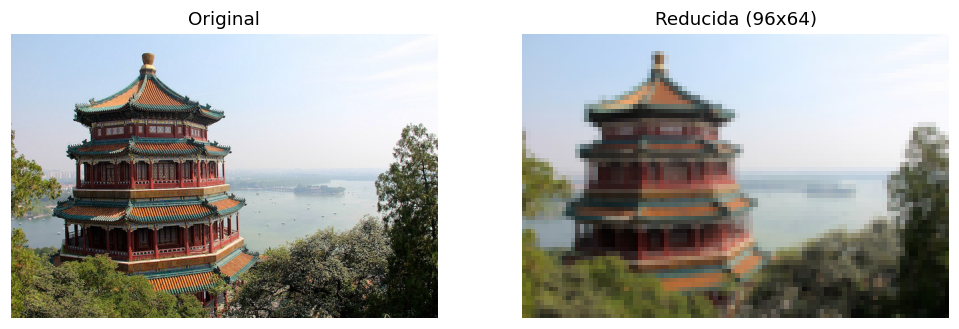

In [2]:
FUENTE = "china"        # "china", "flower" o "subir"
ALTO_REDUCIDO = 64      # alto (px) de la imagen usada en los enfoques A y B


def cargar_imagen(fuente):
    if fuente in ("china", "flower"):
        return load_sample_image(f"{fuente}.jpg")
    from google.colab import files
    from skimage.io import imread
    nombre = list(files.upload().keys())[0]
    return imread(nombre)[..., :3]


img = cargar_imagen(FUENTE)
print("Imagen completa:", img.shape)

alto = ALTO_REDUCIDO
ancho = int(round(img.shape[1] * alto / img.shape[0]))
small = resize(img, (alto, ancho), anti_aliasing=True)   # valores en [0, 1]
print("Imagen reducida:", small.shape, "->", alto * ancho, "píxeles")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(small); ax[1].set_title(f"Reducida ({ancho}x{alto})"); ax[1].axis("off")
plt.show()

## 2. Espacio de características

Cada píxel se representa por su color en **CIELAB** (L = luminosidad, a = verde-rojo, b = azul-amarillo) en lugar de RGB. En Lab la distancia euclídea se parece más a la diferencia de color que percibe el ojo humano, así que agrupar por distancia tiene más sentido visual.

In [3]:
X_lab = rgb2lab(small).reshape(-1, 3)
print("Matriz de características:", X_lab.shape, "(píxeles x [L, a, b])")
pd.DataFrame(X_lab, columns=["L", "a", "b"]).describe().round(1)

Matriz de características: (6144, 3) (píxeles x [L, a, b])


,L,a,b
count,6144.0,6144.0,6144.0
mean,58.7,-0.4,3.2
std,30.5,6.3,12.4
min,1.0,-13.6,-17.9
25%,32.4,-3.3,-5.1
50%,59.4,-1.8,1.2
75%,88.4,0.4,9.2
max,99.3,33.3,43.6


Definimos algunas funciones auxiliares: reconstruir la imagen pintando cada píxel con el color medio de su segmento, y medir la calidad de una segmentación.

Además de las métricas internas habituales (Silhouette, Calinski-Harabasz y Davies-Bouldin), se usan tres específicas de imagen:
- **PSNR** (dB, ↑ mejor): qué tan fiel es la imagen reconstruida con un color por segmento respecto a la original.
- **% en el segmento mayor** (↓ mejor): detecta segmentaciones degeneradas donde un solo grupo se lleva casi todos los píxeles.
- **Componentes conexas** (cercano a *k* es lo ideal): cuántas regiones separadas forman en total los segmentos. Si es mucho mayor que *k*, los segmentos están fragmentados en manchas.

In [4]:
def imagen_segmentada(etiquetas, lab_pixeles, forma):
    """Pinta cada píxel con el color medio (en Lab) de su segmento."""
    ks = np.unique(etiquetas)
    centros = np.array([lab_pixeles[etiquetas == k].mean(axis=0) for k in ks])
    rec = centros[np.searchsorted(ks, etiquetas)]
    return np.clip(lab2rgb(rec.reshape(forma)), 0, 1)


def componentes_conexas(etiquetas2d):
    return sum(ndi.label(etiquetas2d == k)[1] for k in np.unique(etiquetas2d))


def evaluar(etiquetas, lab_pixeles, original_rgb, forma_2d, n_muestra=2000):
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(lab_pixeles), min(n_muestra, len(lab_pixeles)), replace=False)
    rec = imagen_segmentada(etiquetas, lab_pixeles, forma_2d + (3,))
    mse = np.mean((rec - original_rgb) ** 2)
    ok = len(np.unique(etiquetas[idx])) > 1
    return {
        "Silhouette": silhouette_score(lab_pixeles[idx], etiquetas[idx]) if ok else np.nan,
        "Calinski-Harabasz": calinski_harabasz_score(lab_pixeles, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(lab_pixeles, etiquetas),
        "PSNR (dB)": 10 * np.log10(1 / mse),
        "% en segmento mayor": 100 * np.bincount(etiquetas).max() / len(etiquetas),
        "Comp. conexas": componentes_conexas(etiquetas.reshape(forma_2d)),
    }


LINKAGES = ["ward", "complete", "average", "single"]
K = 6   # número de segmentos (se justifica en la sección 6)

## 3. Enfoque A: solo color, con distintos linkages

Los cuatro criterios de enlace definen distinto la distancia entre dos grupos de píxeles:
- **Ward**: fusiona los dos grupos cuya unión aumenta menos la varianza interna.
- **Complete**: distancia entre los dos píxeles *más lejanos* de cada grupo.
- **Average**: distancia *media* entre todos los pares de píxeles.
- **Single**: distancia entre los dos píxeles *más cercanos*.

Aquí solo se usa el color; la posición del píxel no interviene.

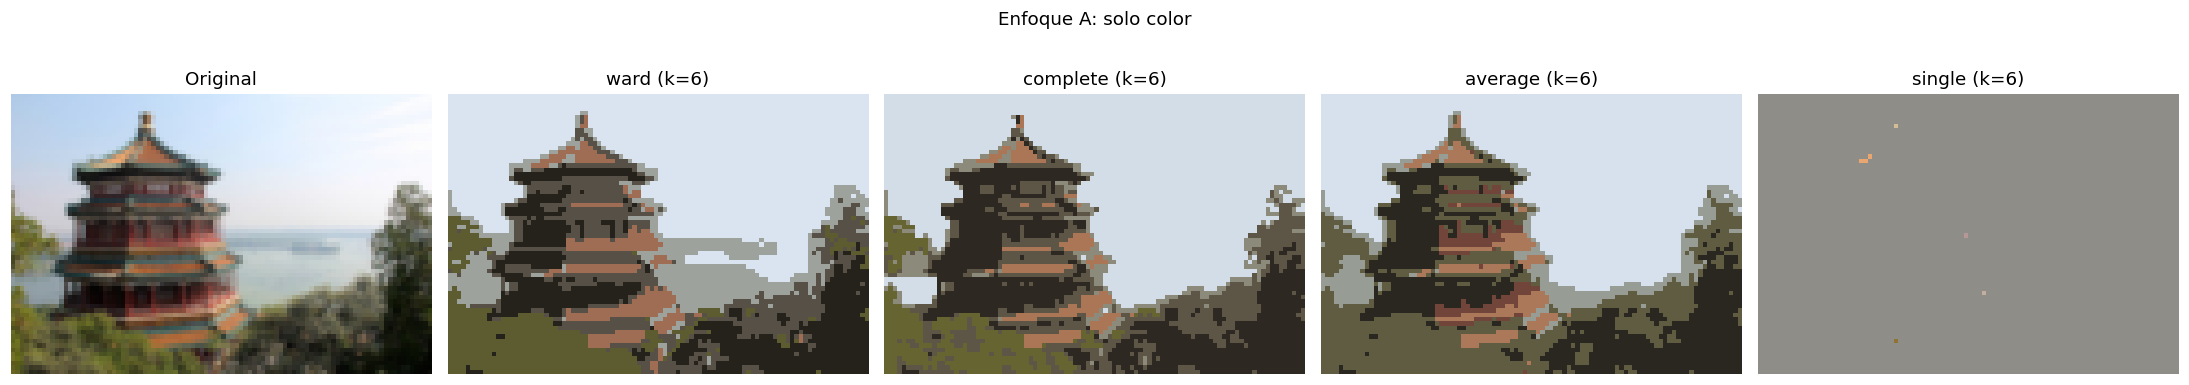

Tamaño de cada segmento:
  ward      [2470  999  947  734  645  349]
  complete  [2896 1298  962  445  311  232]
  average   [2683 1378 1215  441  253  174]
  single    [6137    3    1    1    1    1]


In [5]:
res_A, lab_A = {}, {}
for lk in LINKAGES:
    m = AgglomerativeClustering(n_clusters=K, linkage=lk).fit(X_lab)
    lab_A[lk] = m.labels_
    res_A[lk] = evaluar(m.labels_, X_lab, small, (alto, ancho))

fig, ax = plt.subplots(1, 5, figsize=(20, 3.6))
ax[0].imshow(small); ax[0].set_title("Original")
for a, lk in zip(ax[1:], LINKAGES):
    a.imshow(imagen_segmentada(lab_A[lk], X_lab, (alto, ancho, 3)))
    a.set_title(f"{lk} (k={K})")
for a in ax: a.axis("off")
plt.suptitle("Enfoque A: solo color", y=1.02); plt.tight_layout(); plt.show()

print("Tamaño de cada segmento:")
for lk in LINKAGES:
    print(f"  {lk:9s}", np.sort(np.bincount(lab_A[lk]))[::-1])

## 4. Enfoque B: color con conectividad espacial

Se pasa a `AgglomerativeClustering` un **grafo de conectividad** de la imagen (cada píxel conectado con sus vecinos de la cuadrícula). Así solo se pueden fusionar grupos que sean **adyacentes**, y los segmentos resultantes son regiones continuas, como esperaríamos de una segmentación de objetos.

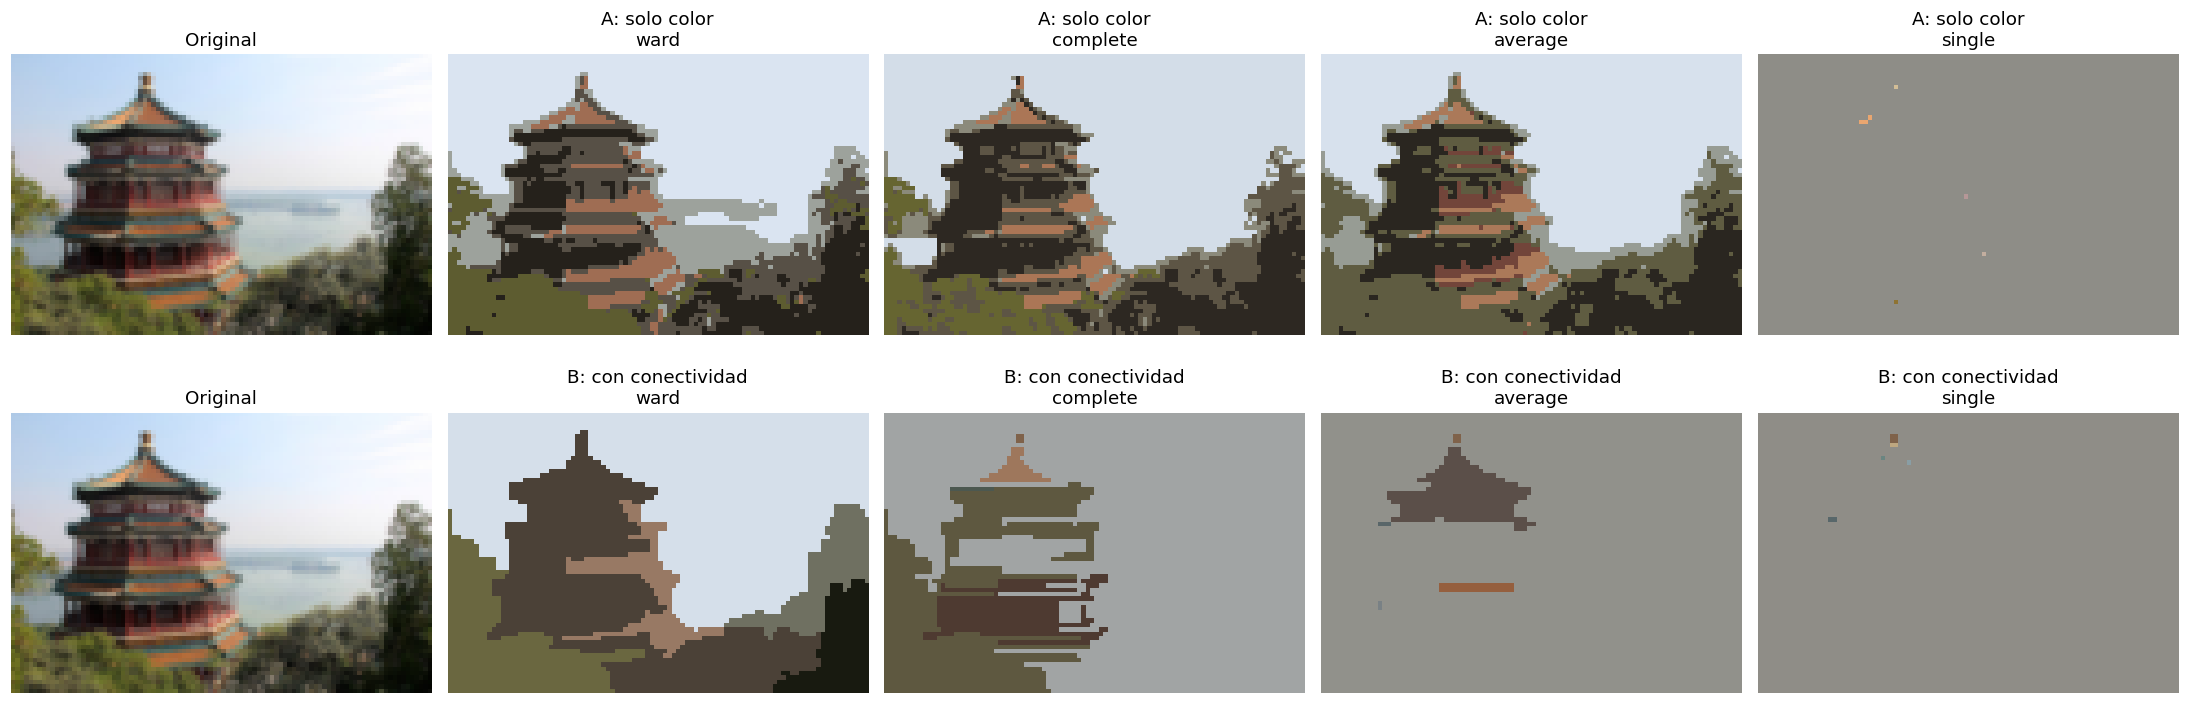

Tamaño de cada segmento (enfoque B):
  ward      [2801 1705  693  336  311  298]
  complete  [4488 1200  387   55   10    4]
  average   [5775  326   34    4    3    2]
  single    [6134    4    2    2    1    1]


In [6]:
conectividad = grid_to_graph(n_x=alto, n_y=ancho)

res_B, lab_B = {}, {}
for lk in LINKAGES:
    m = AgglomerativeClustering(n_clusters=K, linkage=lk, connectivity=conectividad).fit(X_lab)
    lab_B[lk] = m.labels_
    res_B[lk] = evaluar(m.labels_, X_lab, small, (alto, ancho))

fig, ax = plt.subplots(2, 5, figsize=(20, 7))
for fila, (titulo, labs) in enumerate([("A: solo color", lab_A), ("B: con conectividad", lab_B)]):
    ax[fila, 0].imshow(small); ax[fila, 0].set_title("Original")
    for a, lk in zip(ax[fila, 1:], LINKAGES):
        a.imshow(imagen_segmentada(labs[lk], X_lab, (alto, ancho, 3)))
        a.set_title(f"{titulo}\n{lk}")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

print("Tamaño de cada segmento (enfoque B):")
for lk in LINKAGES:
    print(f"  {lk:9s}", np.sort(np.bincount(lab_B[lk]))[::-1])

### Mapa de segmentos con fronteras
Para ver mejor cómo se reparte el espacio, se dibujan las fronteras de cada segmento sobre la imagen original (enfoque B).

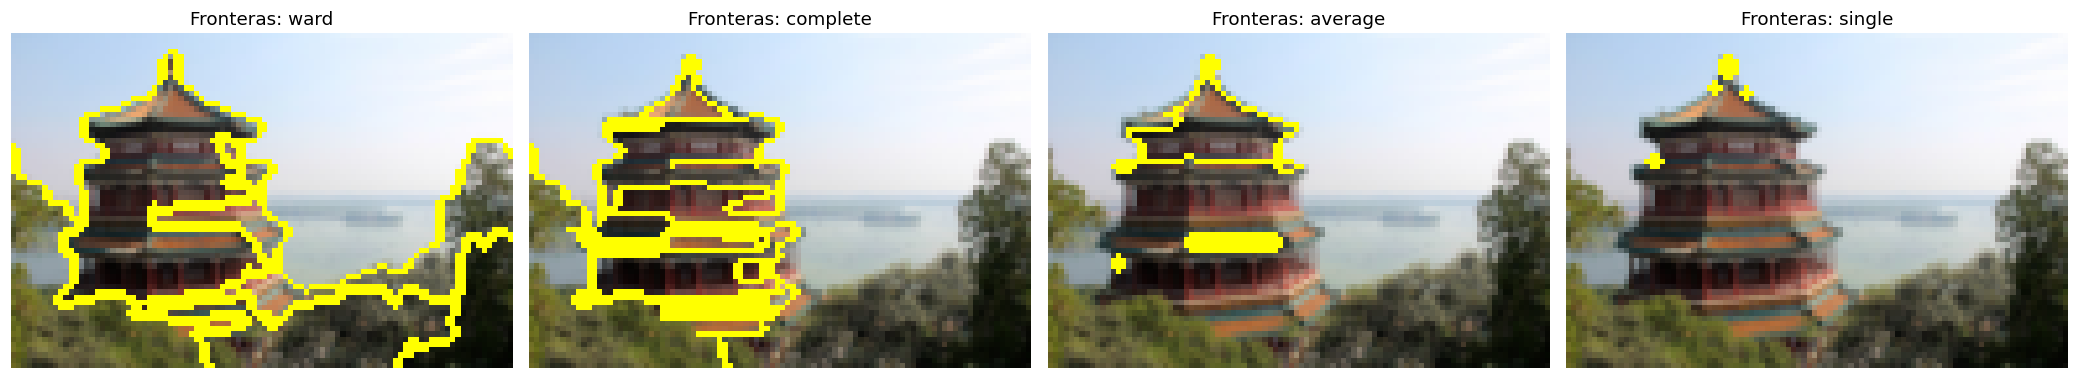

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(19, 3.6))
for a, lk in zip(ax, LINKAGES):
    a.imshow(mark_boundaries(small, lab_B[lk].reshape(alto, ancho), color=(1, 1, 0)))
    a.set_title(f"Fronteras: {lk}"); a.axis("off")
plt.tight_layout(); plt.show()

## 5. Comparación de linkages con métricas

Se calculan las métricas de la sección 2 para los ocho casos (4 linkages x 2 enfoques).

In [8]:
tabla = pd.concat({"A: solo color": pd.DataFrame(res_A).T,
                   "B: con conectividad": pd.DataFrame(res_B).T})
tabla.round(2)

Silhouette  Calinski-Harabasz  Davies-Bouldin  \
A: solo color       ward            0.47           12631.43            0.86   
                    complete        0.48           10775.69            0.88   
                    average         0.48           11015.37            0.87   
                    single         -0.23               1.40            1.57   
B: con conectividad ward            0.36            5998.55            1.41   
                    complete       -0.04             357.31            2.34   
                    average        -0.27              45.33            2.36   
                    single         -0.32               0.71            2.23   

                              PSNR (dB)  % en segmento mayor  Comp. conexas  
A: solo color       ward          22.49                40.20          219.0  
                    complete      21.31                47.14          247.0  
                    average       22.30                43.67          198.0  
                    single         9.90                99.89            7.0  
B: con conectividad ward          19.27                45.59            6.0  
                    complete      11.09                73.05            6.0  
                    average       10.05                93.99            6.0  
                    single         9.90                99.84            6.0

Lectura de la tabla:
- Silhouette, Calinski-Harabasz y Davies-Bouldin miden compacidad y separación **en el espacio de color**. Por eso el enfoque A siempre luce mejor en ellas: no tiene que respetar la posición.
- PSNR y "% en segmento mayor" dicen si la segmentación conserva la imagen o si colapsa.
- "Comp. conexas" muestra el precio del enfoque A: sus *k* segmentos se reparten en muchas manchas separadas.

## 6. Dendrograma y elección del número de segmentos

Para dibujar dendrogramas con `scipy` se usa una **muestra aleatoria de 1.500 píxeles** (un dendrograma con miles de hojas sería ilegible). Además del dendrograma se calcula el **coeficiente de correlación cofenética**: mide qué tan fielmente el árbol conserva las distancias originales entre píxeles (más cercano a 1 es mejor).

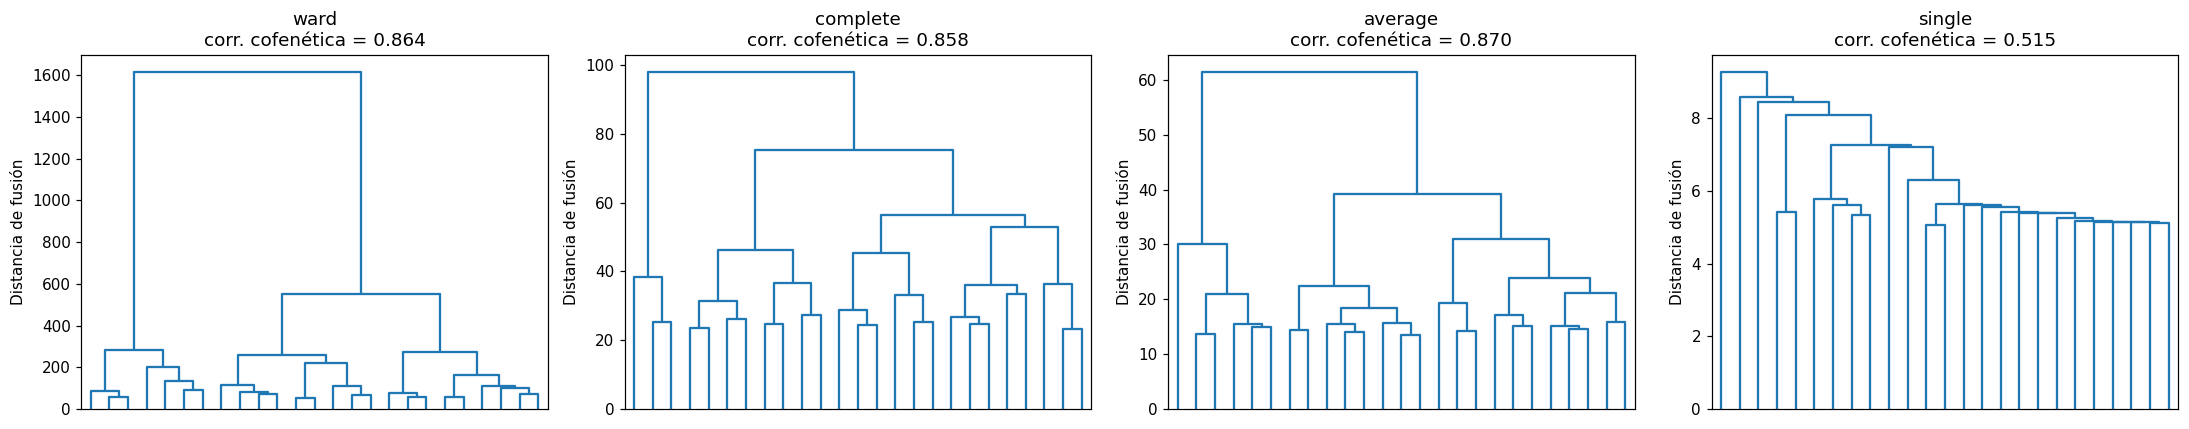

,Correlación cofenética
ward,0.864
complete,0.858
average,0.870
single,0.515


In [9]:
rng = np.random.RandomState(RANDOM_STATE)
muestra = X_lab[rng.choice(len(X_lab), 1500, replace=False)]
dist_muestra = pdist(muestra)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
coph = {}
Z = {}
for a, lk in zip(axes, LINKAGES):
    Z[lk] = linkage(muestra, method=lk)
    coph[lk] = cophenet(Z[lk], dist_muestra)[0]
    dendrogram(Z[lk], truncate_mode="lastp", p=25, no_labels=True, ax=a, color_threshold=0)
    a.set_title(f"{lk}\ncorr. cofenética = {coph[lk]:.3f}")
    a.set_ylabel("Distancia de fusión")
plt.tight_layout(); plt.show()

pd.Series(coph, name="Correlación cofenética").round(3).to_frame()

### ¿Cuántos segmentos elegir?
Se combinan dos criterios con el linkage Ward:
1. **Alturas de fusión:** un salto grande en la distancia de fusión indica que se está uniendo grupos muy distintos, lo que sugiere cortar antes de ese punto.
2. **Silhouette** en función de *k*.

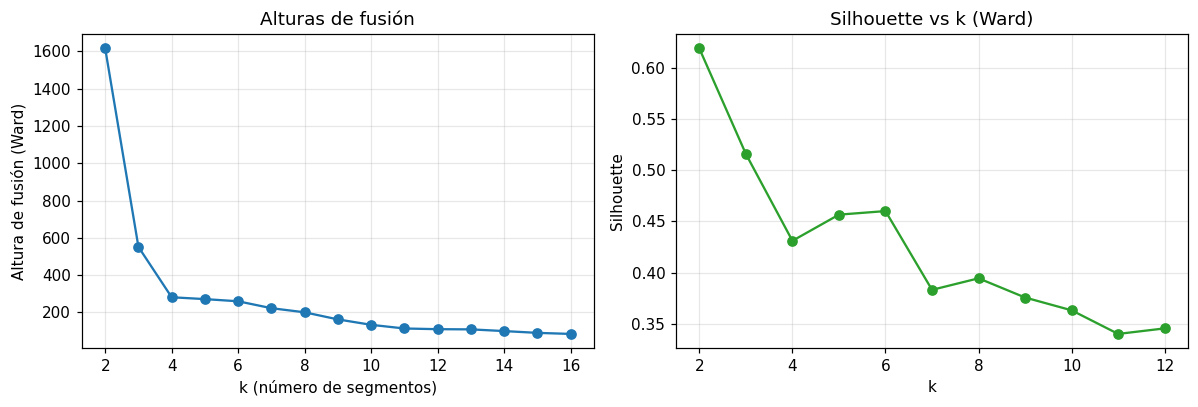

,0,1,2,3,4,5,6,7,8,9,10
k,2.000,3.000,4.000,5.000,6.00,7.000,8.000,9.000,10.000,11.00,12.000
silhouette,0.619,0.516,0.431,0.457,0.46,0.383,0.395,0.376,0.363,0.34,0.346


In [10]:
alturas = Z["ward"][-15:, 2][::-1]          # últimas 15 fusiones (de la más alta a la más baja)
ks_alt = np.arange(2, 2 + len(alturas))     # k que resulta de cortar bajo cada altura

ks = range(2, 13)
sils = []
for k in ks:
    l = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_lab)
    idx = rng.choice(len(X_lab), 2000, replace=False)
    sils.append(silhouette_score(X_lab[idx], l[idx]))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(ks_alt, alturas, "o-"); ax[0].set_xlabel("k (número de segmentos)")
ax[0].set_ylabel("Altura de fusión (Ward)"); ax[0].set_title("Alturas de fusión")
ax[1].plot(list(ks), sils, "o-", color="tab:green"); ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette"); ax[1].set_title("Silhouette vs k (Ward)")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "silhouette": np.round(sils, 3)}).T

Silhouette tiende a preferir pocos segmentos (en imágenes, los colores forman una transición continua y no grupos aislados), mientras que para segmentar una escena queremos suficientes regiones para distinguir objetos. Se fijó **k = 6** como compromiso entre detalle e interpretabilidad. La ventaja del clustering jerárquico es que **no hay que volver a entrenar** para cambiar *k*: se corta el mismo árbol a otro nivel (sección 7).

## 7. Enfoque C: superpíxeles y niveles de la jerarquía

Segmentar los ~273.000 píxeles de la imagen completa con clustering jerárquico no cabe en memoria. La solución habitual es:
1. Agrupar los píxeles en ~250 **superpíxeles** con SLIC (regiones pequeñas y homogéneas).
2. Aplicar el clustering jerárquico sobre los superpíxeles, con conectividad entre superpíxeles vecinos.
3. Devolver la etiqueta a cada píxel.

Así se obtiene una segmentación a **resolución completa** y se puede recorrer la jerarquía a distintos niveles.

Superpíxeles: 245


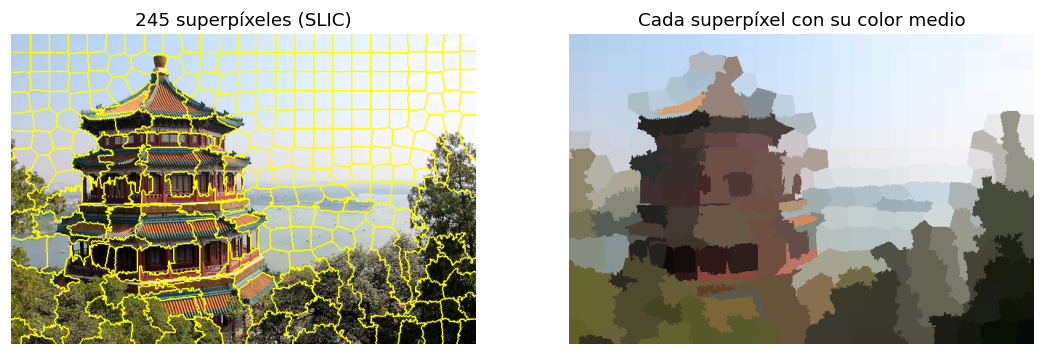

In [11]:
sp = slic(img, n_segments=400, compactness=10, start_label=0)      # mapa de superpíxeles
n_sp = sp.max() + 1
print("Superpíxeles:", n_sp)

# Característica de cada superpíxel: color medio en Lab
lab_full = rgb2lab(img)
X_sp = np.array([lab_full[sp == i].mean(axis=0) for i in range(n_sp)])

# Grafo de adyacencia entre superpíxeles
pares = set()
for a, b in [(sp[:, :-1], sp[:, 1:]), (sp[:-1, :], sp[1:, :])]:
    d = a != b
    pares.update(zip(a[d].tolist(), b[d].tolist()))
filas, cols = zip(*pares)
adyacencia = sparse.coo_matrix((np.ones(len(filas)), (filas, cols)), shape=(n_sp, n_sp)).tocsr()
adyacencia = ((adyacencia + adyacencia.T) > 0).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(mark_boundaries(img, sp)); ax[0].set_title(f"{n_sp} superpíxeles (SLIC)")
ax[1].imshow(lab2rgb(X_sp[sp])); ax[1].set_title("Cada superpíxel con su color medio")
for a in ax: a.axis("off")
plt.show()

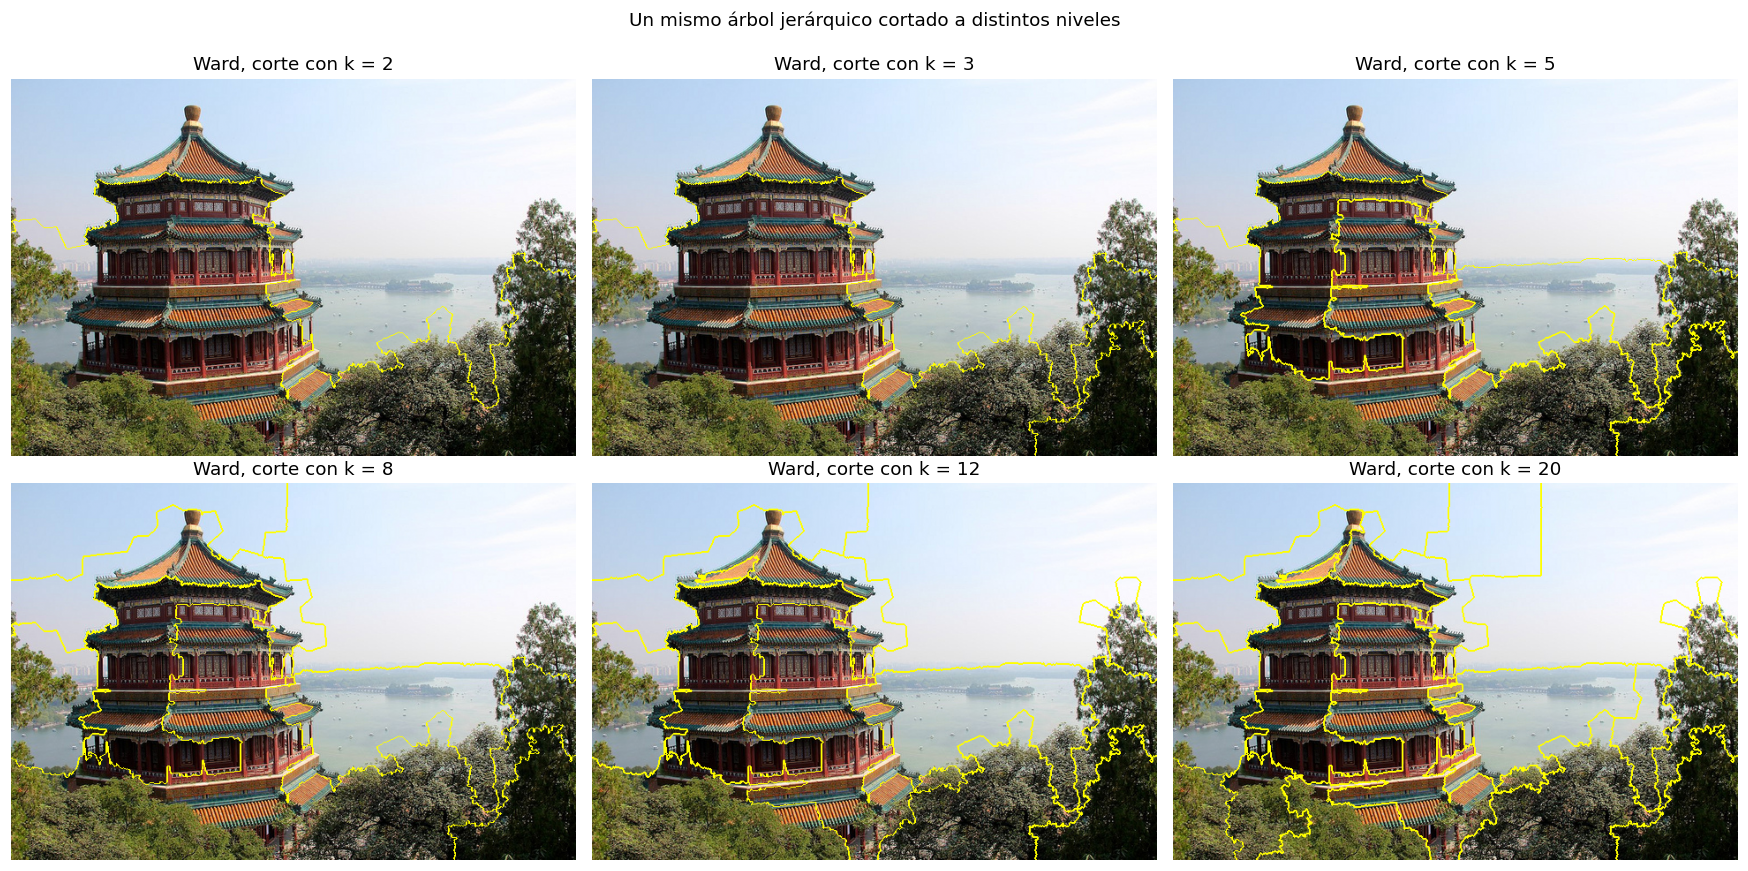

In [12]:
def segmentar_superpixeles(k, linkage_="ward"):
    m = AgglomerativeClustering(n_clusters=k, linkage=linkage_, connectivity=adyacencia).fit(X_sp)
    return m.labels_[sp]     # etiqueta por píxel de la imagen completa

niveles = [2, 3, 5, 8, 12, 20]
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for a, k in zip(ax.ravel(), niveles):
    seg = segmentar_superpixeles(k)
    a.imshow(mark_boundaries(img, seg, color=(1, 1, 0)))
    a.set_title(f"Ward, corte con k = {k}"); a.axis("off")
plt.suptitle("Un mismo árbol jerárquico cortado a distintos niveles", y=1.0)
plt.tight_layout(); plt.show()

### Linkages sobre superpíxeles

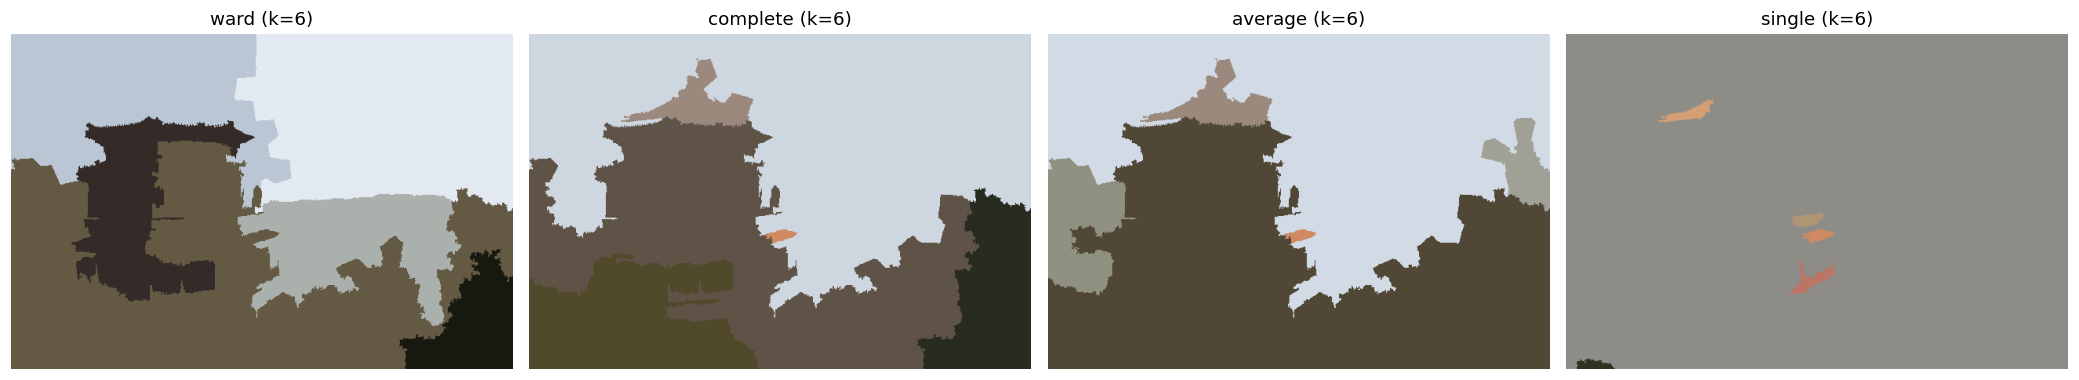

,% en segmento mayor,% en segmento menor,PSNR (dB)
ward,35.7,4.6,15.0
complete,48.2,0.1,14.5
average,47.0,0.1,14.6
single,98.9,0.1,9.4


In [13]:
K_SP = 6
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
filas_tabla = {}
for a, lk in zip(ax, LINKAGES):
    seg = segmentar_superpixeles(K_SP, lk)
    a.imshow(lab2rgb(np.array([lab_full[seg == k].mean(axis=0) for k in range(K_SP)])[seg]))
    a.set_title(f"{lk} (k={K_SP})"); a.axis("off")
    tam = np.bincount(seg.ravel(), minlength=K_SP)
    filas_tabla[lk] = {"% en segmento mayor": 100 * tam.max() / tam.sum(),
                       "% en segmento menor": 100 * tam.min() / tam.sum(),
                       "PSNR (dB)": 10 * np.log10(1 / np.mean((lab2rgb(np.array([lab_full[seg == k].mean(axis=0) for k in range(K_SP)])[seg]) - img / 255.0) ** 2))}
plt.tight_layout(); plt.show()
pd.DataFrame(filas_tabla).T.round(1)

## 8. Segunda imagen
Para comprobar que las conclusiones no dependen de una sola escena, se repite el análisis (Ward vs Single con conectividad, y Ward por superpíxeles) sobre la otra imagen de ejemplo.

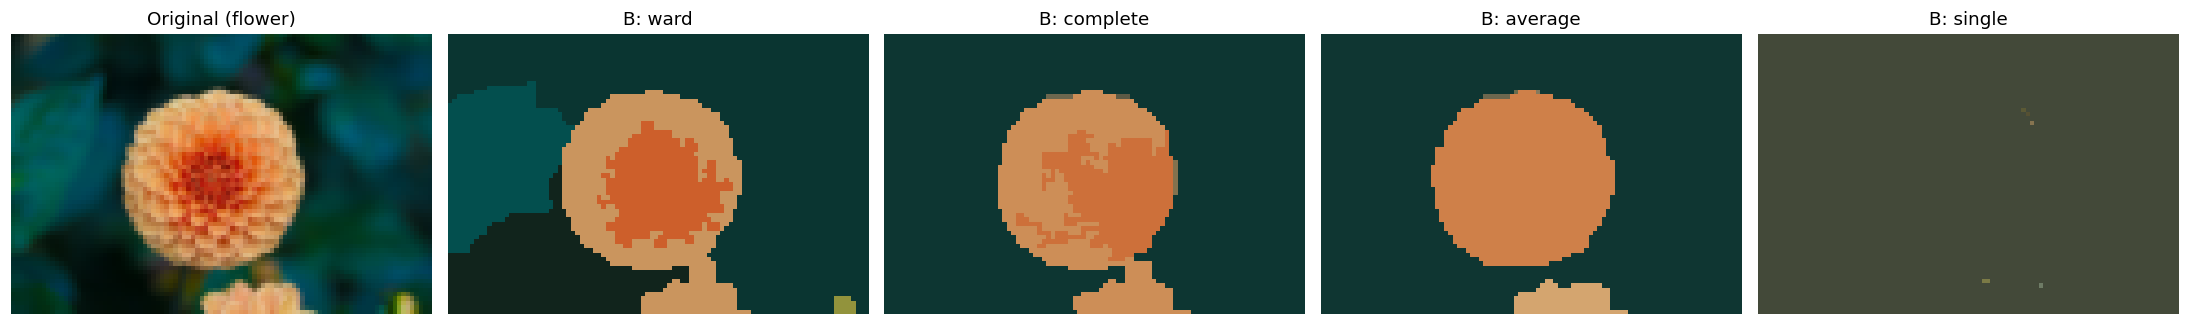

,Silhouette,Calinski-Harabasz,Davies-Bouldin,PSNR (dB),% en segmento mayor,Comp. conexas
ward,0.13,7642.28,1.51,21.85,48.55,6.0
complete,0.14,4774.45,2.27,20.16,75.21,6.0
average,0.36,4481.97,1.65,20.04,75.98,6.0
single,-0.13,0.48,2.03,12.69,99.90,6.0


In [14]:
otra = "flower" if FUENTE == "china" else "china"
img2 = load_sample_image(f"{otra}.jpg")
al2 = ALTO_REDUCIDO; an2 = int(round(img2.shape[1] * al2 / img2.shape[0]))
small2 = resize(img2, (al2, an2), anti_aliasing=True)
X2 = rgb2lab(small2).reshape(-1, 3)
con2 = grid_to_graph(n_x=al2, n_y=an2)

fig, ax = plt.subplots(1, 5, figsize=(20, 3.6))
ax[0].imshow(small2); ax[0].set_title(f"Original ({otra})")
res2 = {}
for a, lk in zip(ax[1:], LINKAGES):
    l = AgglomerativeClustering(n_clusters=K, linkage=lk, connectivity=con2).fit_predict(X2)
    a.imshow(imagen_segmentada(l, X2, (al2, an2, 3))); a.set_title(f"B: {lk}")
    res2[lk] = evaluar(l, X2, small2, (al2, an2))
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
pd.DataFrame(res2).T.round(2)

## 9. Hallazgos y conclusiones

Las cifras siguientes corresponden a la imagen `china.jpg` con *k* = 6. Pueden variar levemente con otra imagen o versión de las librerías, pero el patrón se repite (ver sección 8).

### 1. Ward fue el linkage más exitoso
- **Con conectividad espacial (enfoque B)**, Ward reparte los píxeles en 6 regiones equilibradas (la mayor tiene ~46 % de los píxeles) y reconstruye la imagen con un PSNR de ~19 dB. Complete, Average y Single **colapsan**: el segmento mayor concentra el 73 %, 94 % y 99,8 % de los píxeles, y el PSNR cae a ~10-11 dB, casi el nivel de pintar la imagen de un solo color.
- **Sin conectividad (enfoque A)**, Ward, Complete y Average dan resultados parecidos (PSNR 21-22,5 dB, Silhouette ~0,47-0,48). Single vuelve a fallar: un segmento con el 99,9 % de los píxeles y los otros cinco con 1-3 píxeles cada uno.
- **Sobre superpíxeles (enfoque C)**, Ward vuelve a ser el mejor: su segmento mayor tiene ~36 % de la imagen y el resto está bien repartido, mientras que Single deja ~99 % en un solo segmento.

### 2. Por qué cada linkage se comporta así
- **Single** sufre el *efecto cadena*: en una foto los colores cambian de forma gradual (degradados de cielo, sombras, iluminación), así que siempre hay un píxel intermedio que "une" dos zonas distintas. El resultado es un gran grupo y unos pocos píxeles sueltos. Su correlación cofenética (0,52) es también muy inferior a la de los demás (0,86-0,87), señal de que el árbol representa mal las distancias reales.
- **Complete y Average** son sensibles a los píxeles extremos (brillos, sombras muy oscuras): esos píxeles quedan lejos de todo y terminan formando segmentos diminutos. Cuando además se obliga a fusionar solo vecinos, esos píxeles aislados no pueden integrarse en ningún grupo y el problema se agrava.
- **Ward** minimiza el aumento de varianza en cada fusión, lo que favorece grupos compactos y de tamaño comparable. Encaja con lo que buscamos al segmentar: regiones de color coherente y sin segmentos minúsculos.

### 3. Compromiso entre color y continuidad espacial (A vs B)
- El enfoque A obtiene mejores métricas internas (Silhouette 0,47 y Davies-Bouldin 0,86 con Ward frente a 0,36 y 1,41 en B), pero sus 6 segmentos se reparten en unas **200-250 manchas separadas** (componentes conexas). En la práctica es una *cuantización de color*, no una segmentación de objetos.
- El enfoque B da exactamente 6 regiones continuas, que es lo que esperamos de una segmentación, a costa de peores métricas internas. Esas métricas miden compacidad **en el espacio de color** y no premian la continuidad espacial; por eso hay que leerlas junto con las métricas de imagen.

### 4. Las métricas internas por sí solas pueden engañar
- La correlación cofenética más alta la tuvo Average (0,870), pero como método de segmentación no fue el mejor. Mide la fidelidad del árbol a las distancias, no la calidad visual de los segmentos.
- En la segunda imagen (sección 8), Average obtiene un Silhouette (0,36) mayor que Ward (0,13) aun teniendo ~76 % de los píxeles en un solo segmento. Por eso se usaron también el PSNR, el porcentaje en el segmento mayor y las componentes conexas.
- Silhouette prefirió *k* = 2 (0,62) y bajó al aumentar *k*, porque los colores de una escena natural forman transiciones continuas y no grupos aislados. Para distinguir objetos se necesitan más segmentos, por eso se fijó *k* = 6 con criterio visual.

### 5. Qué aporta la jerarquía
- **Un solo árbol, muchos niveles:** con *k* = 2 se separan solo las grandes zonas de color, y al subir a 8, 12 o 20 aparecen detalles más finos. No hace falta reentrenar para cambiar el nivel de detalle, algo que K-Means sí requiere.
- **Superpíxeles como solución de escala:** el clustering jerárquico necesita memoria cuadrática en el número de píxeles, así que no es viable a resolución completa (~273.000 píxeles). Resumir primero la imagen en ~250 superpíxeles permitió segmentarla completa manteniendo los bordes de los objetos.

### 6. Limitaciones y siguientes pasos
- Solo se usó el **color** como característica. No se captura la textura (césped, agua, tejidos), y un mismo objeto con sombras y luces puede quedar dividido.
- Se evaluó sin segmentación de referencia. Con **BSDS500**, que incluye segmentaciones hechas por personas, se podría aplicar validación externa (por ejemplo, Probabilistic Rand Index o Variation of Information) y elegir el linkage y el *k* con criterios objetivos.
- Mejoras posibles: añadir la posición (x, y) o características de textura, y elegir *k* de forma adaptativa según la imagen.

**Conclusión:** para segmentar imágenes con clustering jerárquico, **Ward con restricción de conectividad** (o Ward sobre superpíxeles) fue la mejor combinación: produce regiones continuas, equilibradas y fieles al color original, mientras que Single es inutilizable por el efecto cadena y Complete/Average son frágiles ante píxeles atípicos.